# Deliverable: Performance Analytics & Risk Metrics

This notebook covers:
1. **Daily Returns:** Verification of daily return distributions across all 40 schemes.
2. **CAGR:** Compounding Annual Growth Rate calculation over 1-year, 3-year, and 5-year horizons.
3. **Sharpe Ratio:** Excess returns relative to risk-free rate ($R_f = 6.5\%$, RBI repo rate proxy).
4. **Sortino Ratio:** Downside performance metrics.
5. **Alpha and Beta:** Ordinary Least Squares (OLS) regressions against Nifty 100 benchmark.
6. **Maximum Drawdown:** Worst peak-to-trough drawdowns and date ranges.
7. **Fund Scorecard (0-100):** Ranks composite indicators.
8. **Benchmark Comparison:** Top 5 funds vs Nifty 50 and Nifty 100 over 3 years, with tracking errors.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
db_path = os.path.join("..", "data", "db", "bluestock_mf.db")
conn = sqlite3.connect(db_path)

## 1. Daily Returns Distribution
We verify daily returns calculated as:
$$\text{daily\_return}_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1$$
And plot the distribution for our representative fund (SBI Bluechip Fund, amfi: 119551).

Daily Returns Distribution Statistics (SBI Bluechip):
count    1607.000000
mean        0.000656
std         0.007330
min        -0.027680
25%        -0.002616
50%         0.000000
75%         0.003999
max         0.035096
Name: returns, dtype: float64


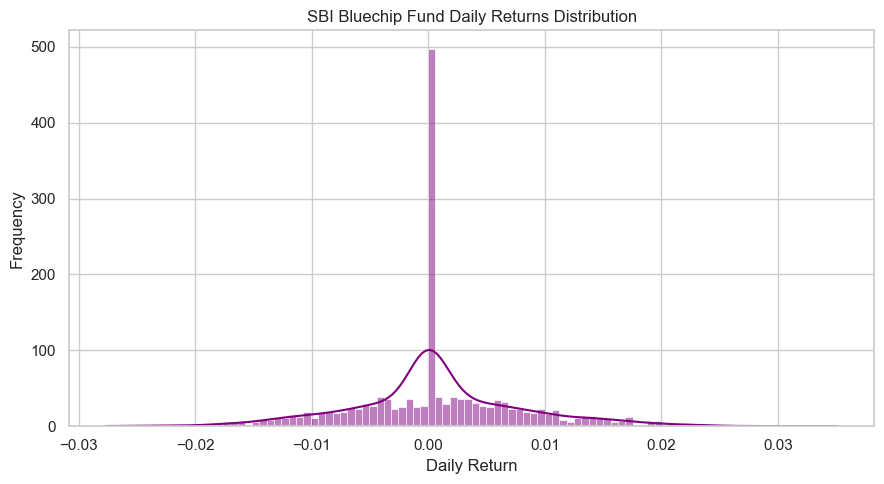

In [2]:
# Fetch returns for SBI Bluechip Fund (119551)
nav_df = pd.read_sql_query("""
    SELECT date, nav FROM fact_nav 
    WHERE amfi_code = 119551 
    ORDER BY date
""", conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df['returns'] = nav_df['nav'].pct_change()

# Print stats
stats = nav_df['returns'].dropna().describe()
print("Daily Returns Distribution Statistics (SBI Bluechip):")
print(stats)

# Plot distribution
plt.figure(figsize=(9, 5))
sns.histplot(nav_df['returns'].dropna(), bins=100, kde=True, color='purple')
plt.title("SBI Bluechip Fund Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 2. CAGR Comparison Table
We show compound annual growth rates calculated over 1-year, 3-year, and 5-year periods:
$$\text{CAGR} = \left(\frac{\text{NAV}_{\text{end}}}{\text{NAV}_{\text{start}}}\right)^{\frac{1}{n}} - 1$$
Where $n$ is duration in calendar years.

In [3]:
# Load generated scorecard table showing all metrics
df_scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

# Display CAGR percentages
cagr_cols = ['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
df_cagr = df_scorecard[cagr_cols].copy()
for col in ['cagr_1yr', 'cagr_3yr', 'cagr_5yr']:
    df_cagr[col] = df_cagr[col] * 100.0

print("Top 15 Funds by 3-Year Annualized CAGR (%):")
print(df_cagr.sort_values('cagr_3yr', ascending=False).head(15).to_string(index=False))

Top 15 Funds by 3-Year Annualized CAGR (%):
                                       scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
               Axis Midcap Fund - Regular - Growth 22.261065 35.111802       NaN
     Mirae Asset Large Cap Fund - Regular - Growth 20.360678 34.000916       NaN
         ICICI Pru Bluechip Fund - Direct - Growth 13.064279 32.487429       NaN
HDFC Mid-Cap Opportunities Fund - Regular - Growth 53.232396 32.442459       NaN
          ICICI Pru Midcap Fund - Regular - Growth 29.604659 31.777537       NaN
         SBI Bluechip Fund - Regular Plan - Growth 60.437341 30.456524       NaN
            Kotak Flexicap Fund - Regular - Growth 26.657082 29.582770       NaN
     Mirae Asset Tax Saver Fund - Regular - Growth 39.751761 29.178902       NaN
     ABSL Frontline Equity Fund - Regular - Growth 47.924120 28.967695       NaN
             DSP Small Cap Fund - Regular - Growth 65.138719 27.000427       NaN
                DSP Midcap Fund - Regular - Growth 21.481222 26.8

## 3. Sharpe & Sortino Ratios (Risk-Free rate = 6.5%)
We compute excess returns relative to a 6.5% annual risk-free benchmark proxy.
$$\text{Sharpe} = \frac{\mu - R_{f,\text{daily}}}{\sigma} \times \sqrt{252}$$
$$\text{Sortino} = \frac{\mu - R_{f,\text{daily}}}{\sigma_{\text{downside}}} \times \sqrt{252}$$

In [4]:
# Display ratios
ratio_cols = ['scheme_name', 'sharpe_ratio', 'sortino_ratio']
df_ratios = df_scorecard[ratio_cols].copy()
print("Top 15 Funds Ranked by Sharpe Ratio:")
print(df_ratios.sort_values('sharpe_ratio', ascending=False).head(15).to_string(index=False))

Top 15 Funds Ranked by Sharpe Ratio:
                                          scheme_name  sharpe_ratio  sortino_ratio
        Mirae Asset Large Cap Fund - Regular - Growth      1.068224       1.490739
               Kotak Flexicap Fund - Regular - Growth      0.965561       1.479503
        Mirae Asset Tax Saver Fund - Regular - Growth      0.919047       1.352815
             ICICI Pru Midcap Fund - Regular - Growth      0.883256       1.285843
            SBI Bluechip Fund - Regular Plan - Growth      0.860977       1.291483
                   DSP Midcap Fund - Regular - Growth      0.832885       1.167793
   HDFC Mid-Cap Opportunities Fund - Regular - Growth      0.808268       1.144216
       Nippon India Large Cap Fund - Regular - Growth      0.758851       1.098880
                  Axis Midcap Fund - Regular - Growth      0.730547       1.055284
        ABSL Frontline Equity Fund - Regular - Growth      0.717409       1.063909
            ICICI Pru Bluechip Fund - Direct - Gro

## 4. Alpha and Beta (vs Nifty 100 Benchmark)
We regress each fund's returns against Nifty 100 to compute Beta (slope) and annualized Alpha (intercept * 252).

In [5]:
ab_cols = ['scheme_name', 'alpha', 'beta']
df_ab = df_scorecard[ab_cols].copy()
print("Top 15 Funds Ranked by Annualized Alpha (intercept * 252):")
print(df_ab.sort_values('alpha', ascending=False).head(15).to_string(index=False))

Top 15 Funds Ranked by Annualized Alpha (intercept * 252):
                                          scheme_name    alpha      beta
           SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196
                DSP Small Cap Fund - Regular - Growth 0.300579  0.011455
             ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549
        Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134
               Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830
   HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104
        Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684
                   DSP Midcap Fund - Regular - Growth 0.265986 -0.002523
                  Axis Midcap Fund - Regular - Growth 0.260767 -0.066265
            SBI Bluechip Fund - Regular Plan - Growth 0.232010 -0.031751
       Nippon India Large Cap Fund - Regular - Growth 0.218294 -0.008354
        ABSL Frontline Equity Fund - Regular - Growth 0.213998  0

## 5. Maximum Drawdown & Date Ranges
Peak-to-trough maximum drawdown tracking details:
$$\text{Drawdown} = \frac{\text{NAV}}{\text{running\_max}} - 1$$

In [6]:
dd_cols = ['scheme_name', 'max_drawdown', 'worst_drawdown_peak_date', 'worst_drawdown_trough_date']
df_dd = df_scorecard[dd_cols].copy()
df_dd['max_drawdown'] = df_dd['max_drawdown'] * 100.0
print("Top 15 Funds with Smallest Peak Drawdowns (Ascending Volatility Risk):")
print(df_dd.sort_values('max_drawdown', ascending=False).head(15).to_string(index=False))

Top 15 Funds with Smallest Peak Drawdowns (Ascending Volatility Risk):
                                         scheme_name  max_drawdown worst_drawdown_peak_date worst_drawdown_trough_date
            ICICI Pru Liquid Fund - Regular - Growth     -0.097731               2025-10-16                 2025-10-20
                Kotak Liquid Fund - Regular - Growth     -0.116293               2024-04-12                 2024-04-30
                 ABSL Liquid Fund - Regular - Growth     -0.162250               2023-09-05                 2023-09-12
        HDFC Short Term Debt Fund - Regular - Growth     -4.308264               2023-05-23                 2023-07-28
        SBI Magnum Gilt Fund - Regular Plan - Growth     -4.328729               2024-09-16                 2025-04-01
Nippon India Gilt Securities Fund - Regular - Growth     -8.316362               2023-02-09                 2024-02-09
          UTI Nifty 50 Index Fund - Regular - Growth    -10.859862               2022-02-03     

## 6. Composite Fund Scorecard
Ranks all 40 funds on a 0-100 weighted index using:
- 30% × 3yr Return Rank
- 25% × Sharpe Rank
- 20% × Alpha Rank
- 15% × Expense Ratio Rank (inverse)
- 10% × Max Drawdown Rank (inverse)

In [7]:
print("Top 15 Funds on Composite Scorecard (0-100 score):")
print(df_scorecard[['scheme_name', 'score', 'cagr_3yr', 'sharpe_ratio', 'alpha']].head(15).to_string(index=False))

Top 15 Funds on Composite Scorecard (0-100 score):
                                       scheme_name   score  cagr_3yr  sharpe_ratio    alpha
     Mirae Asset Large Cap Fund - Regular - Growth 86.2500  0.340009      1.068224 0.269838
          ICICI Pru Midcap Fund - Regular - Growth 82.8750  0.317775      0.883256 0.292636
            Kotak Flexicap Fund - Regular - Growth 82.0000  0.295828      0.965561 0.273305
HDFC Mid-Cap Opportunities Fund - Regular - Growth 80.7500  0.324425      0.808268 0.271954
         ICICI Pru Bluechip Fund - Direct - Growth 79.3750  0.324874      0.714682 0.211948
               Axis Midcap Fund - Regular - Growth 78.2500  0.351118      0.730547 0.260767
         SBI Bluechip Fund - Regular Plan - Growth 74.1875  0.304565      0.860977 0.232010
     Mirae Asset Tax Saver Fund - Regular - Growth 73.6875  0.291789      0.919047 0.282704
        SBI Small Cap Fund - Regular Plan - Growth 68.0000  0.266699      0.711690 0.303370
     ABSL Frontline Equity Fu

## 7. Benchmark Comparison Chart & Tracking Error
Shows tracking errors computed as:
$$\text{Tracking Error} = \text{std}(\text{fund\_return} - \text{benchmark\_return}) \times \sqrt{252}$$
And displays the normalized returns chart over 3 years.

Tracking Errors (vs Nifty 100) for Top Funds:
                                       scheme_name  tracking_error
     Mirae Asset Large Cap Fund - Regular - Growth        0.189664
          ICICI Pru Midcap Fund - Regular - Growth        0.231968
            Kotak Flexicap Fund - Regular - Growth        0.206425
HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.228699
         ICICI Pru Bluechip Fund - Direct - Growth        0.191587
               Axis Midcap Fund - Regular - Growth        0.237652
         SBI Bluechip Fund - Regular Plan - Growth        0.191183
     Mirae Asset Tax Saver Fund - Regular - Growth        0.217365
        SBI Small Cap Fund - Regular Plan - Growth        0.283881
     ABSL Frontline Equity Fund - Regular - Growth        0.192706


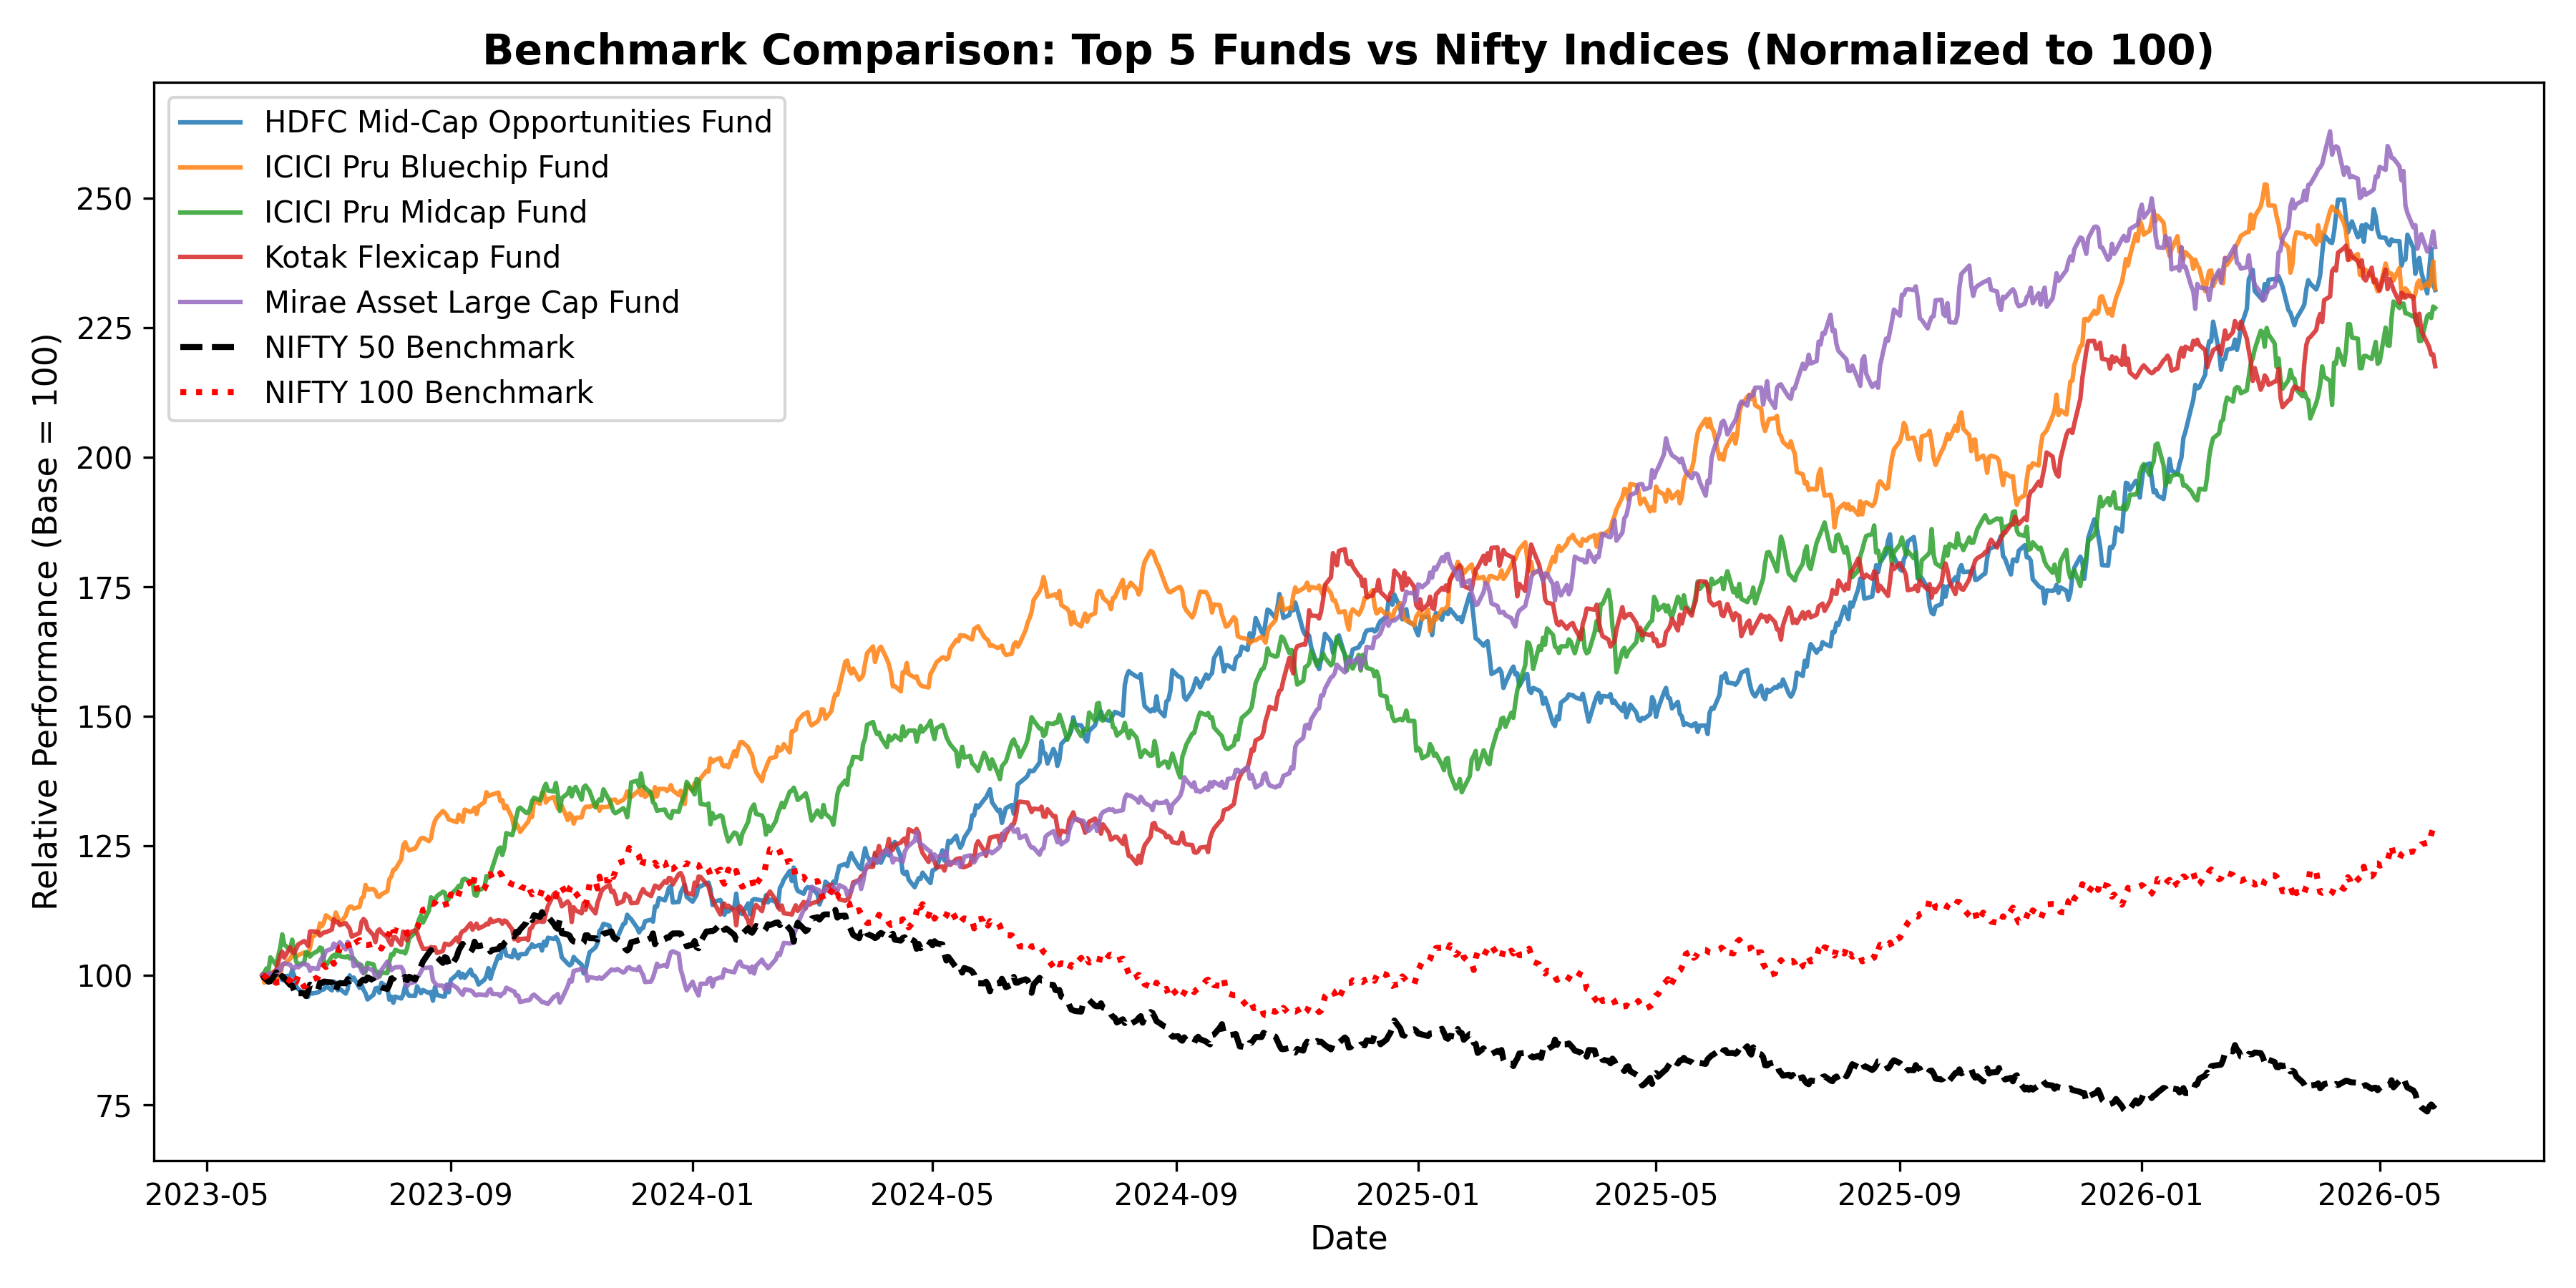

In [8]:
print("Tracking Errors (vs Nifty 100) for Top Funds:")
print(df_scorecard[['scheme_name', 'tracking_error']].head(10).to_string(index=False))

from IPython.display import Image, display
display(Image(filename='../reports/figures/benchmark_comparison.png'))

In [9]:
conn.close()